In [62]:
import pandas as pd

# Leer el CSV
df_2074 = pd.read_csv(
    "../data/viajeros_pernoctaciones_2074_11_05.csv",
    sep=";",
    encoding="latin1"
)

In [63]:
# Ver las primeras filas del dataset
df_2074.head()

,Totales Territoriales,Comunidades y Ciudades Autónomas,Provincias,Residencia: Nivel 1,Residencia: Nivel 2,Viajeros y pernoctaciones,Periodo,Total
0,Total Nacional,01 Andalucía,NaN,Total,Residentes en España,Viajero,2026M03,787.339
1,Total Nacional,01 Andalucía,NaN,Total,Residentes en España,Viajero,2026M02,614.920
2,Total Nacional,01 Andalucía,NaN,Total,Residentes en España,Viajero,2026M01,538.799
3,Total Nacional,01 Andalucía,NaN,Total,Residentes en España,Viajero,2025M12,685.108
4,Total Nacional,01 Andalucía,NaN,Total,Residentes en España,Viajero,2025M11,685.893


In [64]:
# Ver las columnas del dataset
df_2074.columns

Index(['Totales Territoriales', 'Comunidades y Ciudades Autónomas',
       'Provincias', 'Residencia: Nivel 1', 'Residencia: Nivel 2',
       'Viajeros y pernoctaciones', 'Periodo', 'Total'],
      dtype='object')

In [65]:
# Ver los datatypes de cada columna
df_2074.dtypes

Totales Territoriales               object
Comunidades y Ciudades Autónomas    object
Provincias                          object
Residencia: Nivel 1                 object
Residencia: Nivel 2                 object
Viajeros y pernoctaciones           object
Periodo                             object
Total                               object
dtype: object

In [66]:
# Ver cantidad de valores nulos por columna
df_2074.isna().sum()

Totales Territoriales                  0
Comunidades y Ciudades Autónomas       0
Provincias                          3876
Residencia: Nivel 1                    0
Residencia: Nivel 2                    0
Viajeros y pernoctaciones              0
Periodo                                0
Total                                  0
dtype: int64

In [67]:
# Eliminar columna innecesaria porque siempre tiene el mismo valor
df_2074["Totales Territoriales"].dropna().unique()

array(['Total Nacional'], dtype=object)

In [68]:
# Ver valores únicos de Comunidades y Ciudades Autónomas
df_2074["Comunidades y Ciudades Autónomas"].dropna().unique()

array(['01 Andalucía', '02 Aragón', '03 Asturias, Principado de',
       '04 Balears, Illes', '05 Canarias', '06 Cantabria',
       '07 Castilla y León', '08 Castilla - La Mancha', '09 Cataluña',
       '10 Comunitat Valenciana', '11 Extremadura', '12 Galicia',
       '13 Madrid, Comunidad de', '14 Murcia, Región de',
       '15 Navarra, Comunidad Foral de', '16 País Vasco', '17 Rioja, La',
       '18 Ceuta', '19 Melilla'], dtype=object)

In [69]:
# Ver valores únicos de Provincias
df_2074["Provincias"].dropna().unique()

array(['04 Almería', '11 Cádiz', '14 Córdoba', '18 Granada', '21 Huelva',
       '23 Jaén', '29 Málaga', '41 Sevilla', '22 Huesca', '44 Teruel',
       '50 Zaragoza', '33 Asturias', '07 Balears, Illes',
       '35 Palmas, Las', '38 Santa Cruz de Tenerife', '39 Cantabria',
       '05 Ávila', '09 Burgos', '24 León', '34 Palencia', '37 Salamanca',
       '40 Segovia', '42 Soria', '47 Valladolid', '49 Zamora',
       '02 Albacete', '13 Ciudad Real', '16 Cuenca', '19 Guadalajara',
       '45 Toledo', '08 Barcelona', '17 Girona', '25 Lleida',
       '43 Tarragona', '03 Alicante/Alacant', '12 Castellón/Castelló',
       '46 Valencia/València', '06 Badajoz', '10 Cáceres', '15 Coruña, A',
       '27 Lugo', '32 Ourense', '36 Pontevedra', '28 Madrid', '30 Murcia',
       '31 Navarra', '01 Araba/Álava', '48 Bizkaia', '20 Gipuzkoa',
       '26 Rioja, La'], dtype=object)

In [70]:
# Ver Andalucía en un periodo concreto
df_2074[
    (df_2074["Comunidades y Ciudades Autónomas"] == "01 Andalucía") &
    (df_2074["Periodo"] == "2022M01")
].head(20)

,Totales Territoriales,Comunidades y Ciudades Autónomas,Provincias,Residencia: Nivel 1,Residencia: Nivel 2,Viajeros y pernoctaciones,Periodo,Total
50,Total Nacional,01 Andalucía,NaN,Total,Residentes en España,Viajero,2022M01,462.136
101,Total Nacional,01 Andalucía,NaN,Total,Residentes en España,Pernoctaciones,2022M01,826.684
152,Total Nacional,01 Andalucía,NaN,Total,Residentes en el Extranjero,Viajero,2022M01,232.478
203,Total Nacional,01 Andalucía,NaN,Total,Residentes en el Extranjero,Pernoctaciones,2022M01,636.977
254,Total Nacional,01 Andalucía,04 Almería,Total,Residentes en España,Viajero,2022M01,22.290
305,Total Nacional,01 Andalucía,04 Almería,Total,Residentes en España,Pernoctaciones,2022M01,40.808
356,Total Nacional,01 Andalucía,04 Almería,Total,Residentes en el Extranjero,Viajero,2022M01,9.007
407,Total Nacional,01 Andalucía,04 Almería,Total,Residentes en el Extranjero,Pernoctaciones,2022M01,25.143
458,Total Nacional,01 Andalucía,11 Cádiz,Total,Residentes en España,Viajero,2022M01,49.164
509,Total Nacional,01 Andalucía,11 Cádiz,Total,Residentes en España,Pernoctaciones,2022M01,89.031


In [71]:
# Eliminar filas agregadas de comunidad autónoma
# df_2074 = df_2074[
#    df_2074["Provincias"].notna()
# ].copy()

In [72]:
# Crear columna de fecha para ordenar y graficar
df_2074["Periodo fecha"] = pd.to_datetime(
    df_2074["Periodo"].str.replace("M", "-"),
    format="%Y-%m"
)

In [73]:
# Limpiar códigos numéricos al inicio de comunidades autónomas
df_2074["Comunidades y Ciudades Autónomas"] = (
    df_2074["Comunidades y Ciudades Autónomas"]
    .str.replace(r"^\d+\s+", "", regex=True)
)

In [74]:
# Limpiar códigos numéricos al inicio de provincias
df_2074["Provincias"] = (
    df_2074["Provincias"]
    .str.replace(r"^\d+\s+", "", regex=True)
)

In [75]:
# Crear columna numérica a partir de Total
df_2074["Total limpio"] = (
    df_2074["Total"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False)
)

df_2074["Total limpio"] = pd.to_numeric(
    df_2074["Total limpio"],
    errors="coerce"
)

In [76]:
# Revisar nulos después de convertir Total
df_2074.isna().sum()

Totales Territoriales                  0
Comunidades y Ciudades Autónomas       0
Provincias                          3876
Residencia: Nivel 1                    0
Residencia: Nivel 2                    0
Viajeros y pernoctaciones              0
Periodo                                0
Total                                  0
Periodo fecha                          0
Total limpio                           1
dtype: int64

In [77]:
# Ver la fila donde Total limpio es nulo
df_2074[
    df_2074["Total limpio"].isna()
]

,Totales Territoriales,Comunidades y Ciudades Autónomas,Provincias,Residencia: Nivel 1,Residencia: Nivel 2,Viajeros y pernoctaciones,Periodo,Total,Periodo fecha,Total limpio
753,Total Nacional,Andalucía,Córdoba,Total,Residentes en el Extranjero,Viajero,2022M12,.,2022-12-01,NaN


In [78]:
# Ver valores únicos de Viajeros y pernoctaciones
df_2074["Viajeros y pernoctaciones"].dropna().unique()

array(['Viajero', 'Pernoctaciones'], dtype=object)

In [79]:
# Ver valores únicos de Residencia: Nivel 1
df_2074["Residencia: Nivel 1"].dropna().unique()

array(['Total'], dtype=object)

In [80]:
# Ver valores únicos de Residencia: Nivel 2
df_2074["Residencia: Nivel 2"].dropna().unique()

array(['Residentes en España', 'Residentes en el Extranjero'],
      dtype=object)

In [81]:
# Crear columna limpia de residencia
df_2074["Residencia"] = (
    df_2074["Residencia: Nivel 2"]
    .fillna("Total")
)

In [82]:
# Eliminar columna innecesaria
df_2074 = df_2074.drop(columns=["Residencia: Nivel 1"])

In [83]:
# Crear columna territorial limpia para provincia
df_2074["Provincia limpia"] = (
    df_2074["Provincias"]
    .fillna("Total comunidad autónoma")
)

In [84]:
# Crear tabla pivotada manteniendo comunidad autónoma y provincia
df_2074_pivot = df_2074.pivot_table(
    index=[
        "Comunidades y Ciudades Autónomas",
        "Provincia limpia",
        "Residencia",
        "Periodo",
        "Periodo fecha"
    ],
    columns="Viajeros y pernoctaciones",
    values="Total limpio",
    aggfunc="first"
).reset_index()

# Renombrar columna Viajero
df_2074_pivot = df_2074_pivot.rename(columns={
    "Viajero": "Viajeros"
})

# Eliminar el nombre del eje de columnas
df_2074_pivot.columns.name = None

df_2074_pivot

,Comunidades y Ciudades Autónomas,Provincia limpia,Residencia,Periodo,Periodo fecha,Pernoctaciones,Viajeros
0,Andalucía,Almería,Residentes en España,2022M01,2022-01-01,40808.0,22290.0
1,Andalucía,Almería,Residentes en España,2022M02,2022-02-01,69288.0,39146.0
2,Andalucía,Almería,Residentes en España,2022M03,2022-03-01,124044.0,42511.0
3,Andalucía,Almería,Residentes en España,2022M04,2022-04-01,205526.0,70416.0
4,Andalucía,Almería,Residentes en España,2022M05,2022-05-01,261272.0,90422.0
...,...,...,...,...,...,...,...
7033,"Rioja, La",Total comunidad autónoma,Residentes en el Extranjero,2025M11,2025-11-01,13368.0,6889.0
7034,"Rioja, La",Total comunidad autónoma,Residentes en el Extranjero,2025M12,2025-12-01,9031.0,4910.0
7035,"Rioja, La",Total comunidad autónoma,Residentes en el Extranjero,2026M01,2026-01-01,7738.0,3974.0
7036,"Rioja, La",Total comunidad autónoma,Residentes en el Extranjero,2026M02,2026-02-01,7490.0,3959.0


In [85]:
# Ver datatypes después de limpiar el nombre de columnas
df_2074_pivot.dtypes

Comunidades y Ciudades Autónomas            object
Provincia limpia                            object
Residencia                                  object
Periodo                                     object
Periodo fecha                       datetime64[ns]
Pernoctaciones                             float64
Viajeros                                   float64
dtype: object

In [86]:
# Ver cantidad de valores nulos por columna
df_2074_pivot.isna().sum()

Comunidades y Ciudades Autónomas    0
Provincia limpia                    0
Residencia                          0
Periodo                             0
Periodo fecha                       0
Pernoctaciones                      0
Viajeros                            1
dtype: int64

In [87]:
# Ver valores únicos de Provincia limpia >> nuevo valor Total comunidad autónoma
df_2074_pivot["Provincia limpia"].unique()

array(['Almería', 'Cádiz', 'Córdoba', 'Granada', 'Huelva', 'Jaén',
       'Málaga', 'Sevilla', 'Total comunidad autónoma', 'Huesca',
       'Teruel', 'Zaragoza', 'Asturias', 'Balears, Illes', 'Palmas, Las',
       'Santa Cruz de Tenerife', 'Cantabria', 'Albacete', 'Ciudad Real',
       'Cuenca', 'Guadalajara', 'Toledo', 'Burgos', 'León', 'Palencia',
       'Salamanca', 'Segovia', 'Soria', 'Valladolid', 'Zamora', 'Ávila',
       'Barcelona', 'Girona', 'Lleida', 'Tarragona', 'Alicante/Alacant',
       'Castellón/Castelló', 'Valencia/València', 'Badajoz', 'Cáceres',
       'Coruña, A', 'Lugo', 'Ourense', 'Pontevedra', 'Madrid', 'Murcia',
       'Navarra', 'Araba/Álava', 'Bizkaia', 'Gipuzkoa', 'Rioja, La'],
      dtype=object)

In [88]:
# Ejemplo: comprobar si la suma de provincias coincide con el agregado de Andalucía
# enero 2022 - residentes en España

# Filas de provincias reales
provincias = df_2074_pivot[
    (df_2074_pivot["Comunidades y Ciudades Autónomas"] == "Andalucía") &
    (df_2074_pivot["Provincia limpia"] != "Total comunidad autónoma") &
    (df_2074_pivot["Residencia"] == "Residentes en España") &
    (df_2074_pivot["Periodo"] == "2022M01")
]

# Fila agregada oficial del INE
agregado = df_2074_pivot[
    (df_2074_pivot["Comunidades y Ciudades Autónomas"] == "Andalucía") &
    (df_2074_pivot["Provincia limpia"] == "Total comunidad autónoma") &
    (df_2074_pivot["Residencia"] == "Residentes en España") &
    (df_2074_pivot["Periodo"] == "2022M01")
]

# Sumar provincias
suma_viajeros = provincias["Viajeros"].sum()
suma_pernoctaciones = provincias["Pernoctaciones"].sum()

# Obtener agregado oficial
agregado_viajeros = agregado["Viajeros"].iloc[0]
agregado_pernoctaciones = agregado["Pernoctaciones"].iloc[0]

# Mostrar resultados
print("SUMA DE PROVINCIAS")
print("Viajeros:", suma_viajeros)
print("Pernoctaciones:", suma_pernoctaciones)

print("\nAGREGADO OFICIAL INE")
print("Viajeros:", agregado_viajeros)
print("Pernoctaciones:", agregado_pernoctaciones)

print("\nDIFERENCIA")
print("Viajeros:", suma_viajeros - agregado_viajeros)
print("Pernoctaciones:", suma_pernoctaciones - agregado_pernoctaciones)


SUMA DE PROVINCIAS
Viajeros: 462136.0
Pernoctaciones: 826683.0

AGREGADO OFICIAL INE
Viajeros: 462136.0
Pernoctaciones: 826684.0

DIFERENCIA
Viajeros: 0.0
Pernoctaciones: -1.0


se quieremo limpiar los totales:

In [89]:
# # Quedarse solo con provincias reales
# df_2074_pivot = df_2074_pivot[
#     df_2074_pivot["Provincia limpia"] != "Total comunidad autónoma"
# ].copy()

# # Eliminar total residencia
# df_2074_pivot = df_2074_pivot[
#     df_2074_pivot["Residencia"] != "Total"
# ].copy()

# Estancia media

In [90]:
# Cargar el CSV de estancia media
df_2065 = pd.read_csv(
    "../data/estancia_media_2065_11_05.csv",
    sep=";",
    encoding="latin1"
)

# Ver las primeras filas
df_2065.head()


,Totales Territoriales,Comunidades y Ciudades Autónomas,Provincias,Periodo,Total
0,Total Nacional,01 Andalucía,NaN,2026M03,"2,59"
1,Total Nacional,01 Andalucía,NaN,2026M02,"2,42"
2,Total Nacional,01 Andalucía,NaN,2026M01,"2,42"
3,Total Nacional,01 Andalucía,NaN,2025M12,"2,25"
4,Total Nacional,01 Andalucía,NaN,2025M11,"2,41"


In [91]:
# Ver las columnas del dataset
df_2065.columns

Index(['Totales Territoriales', 'Comunidades y Ciudades Autónomas',
       'Provincias', 'Periodo', 'Total'],
      dtype='object')

In [92]:
# Ver los datatypes de cada columna
df_2065.dtypes

Totales Territoriales               object
Comunidades y Ciudades Autónomas    object
Provincias                          object
Periodo                             object
Total                               object
dtype: object

In [93]:
# Ver cantidad de valores nulos por columna
df_2065.isna().sum()

Totales Territoriales                 0
Comunidades y Ciudades Autónomas      0
Provincias                          969
Periodo                               0
Total                                 0
dtype: int64

In [94]:
# Ver valores únicos de Periodo
df_2065["Totales Territoriales"].dropna().unique()

array(['Total Nacional'], dtype=object)

In [95]:
# Eliminar columna innecesaria
df_2065 = df_2065.drop(columns=["Totales Territoriales"])

In [96]:
# Ver valores únicos de Comunidades y Ciudades Autónomas
df_2065["Comunidades y Ciudades Autónomas"].dropna().unique()

array(['01 Andalucía', '02 Aragón', '03 Asturias, Principado de',
       '04 Balears, Illes', '05 Canarias', '06 Cantabria',
       '07 Castilla y León', '08 Castilla - La Mancha', '09 Cataluña',
       '10 Comunitat Valenciana', '11 Extremadura', '12 Galicia',
       '13 Madrid, Comunidad de', '14 Murcia, Región de',
       '15 Navarra, Comunidad Foral de', '16 País Vasco', '17 Rioja, La',
       '18 Ceuta', '19 Melilla'], dtype=object)

In [97]:
# Eliminar códigos numéricos al inicio
df_2065.loc[:, "Comunidades y Ciudades Autónomas"] = (
    df_2065["Comunidades y Ciudades Autónomas"]
    .str.replace(r"^\d+\s+", "", regex=True)
)

#compruebo:
# Valores únicos de Comunidades y Ciudades Autónomas
df_2065["Comunidades y Ciudades Autónomas"].dropna().unique()

array(['Andalucía', 'Aragón', 'Asturias, Principado de', 'Balears, Illes',
       'Canarias', 'Cantabria', 'Castilla y León', 'Castilla - La Mancha',
       'Cataluña', 'Comunitat Valenciana', 'Extremadura', 'Galicia',
       'Madrid, Comunidad de', 'Murcia, Región de',
       'Navarra, Comunidad Foral de', 'País Vasco', 'Rioja, La', 'Ceuta',
       'Melilla'], dtype=object)

In [98]:
# Ver valores únicos de Provincias
df_2065["Provincias"].dropna().unique()

array(['04 Almería', '11 Cádiz', '14 Córdoba', '18 Granada', '21 Huelva',
       '23 Jaén', '29 Málaga', '41 Sevilla', '22 Huesca', '44 Teruel',
       '50 Zaragoza', '35 Palmas, Las', '38 Santa Cruz de Tenerife',
       '05 Ávila', '09 Burgos', '24 León', '34 Palencia', '37 Salamanca',
       '40 Segovia', '42 Soria', '47 Valladolid', '49 Zamora',
       '02 Albacete', '13 Ciudad Real', '16 Cuenca', '19 Guadalajara',
       '45 Toledo', '08 Barcelona', '17 Girona', '25 Lleida',
       '43 Tarragona', '03 Alicante/Alacant', '12 Castellón/Castelló',
       '46 Valencia/València', '06 Badajoz', '10 Cáceres', '15 Coruña, A',
       '27 Lugo', '32 Ourense', '36 Pontevedra', '01 Araba/Álava',
       '48 Bizkaia', '20 Gipuzkoa'], dtype=object)

In [99]:
# Eliminar códigos numéricos al inicio
df_2065.loc[:, "Provincias"] = (
    df_2065["Provincias"]
    .str.replace(r"^\d+\s+", "", regex=True)
)

#compruebo:
# Valores únicos de Provincias
df_2065["Provincias"].dropna().unique()

array(['Almería', 'Cádiz', 'Córdoba', 'Granada', 'Huelva', 'Jaén',
       'Málaga', 'Sevilla', 'Huesca', 'Teruel', 'Zaragoza', 'Palmas, Las',
       'Santa Cruz de Tenerife', 'Ávila', 'Burgos', 'León', 'Palencia',
       'Salamanca', 'Segovia', 'Soria', 'Valladolid', 'Zamora',
       'Albacete', 'Ciudad Real', 'Cuenca', 'Guadalajara', 'Toledo',
       'Barcelona', 'Girona', 'Lleida', 'Tarragona', 'Alicante/Alacant',
       'Castellón/Castelló', 'Valencia/València', 'Badajoz', 'Cáceres',
       'Coruña, A', 'Lugo', 'Ourense', 'Pontevedra', 'Araba/Álava',
       'Bizkaia', 'Gipuzkoa'], dtype=object)

In [100]:
# Ver filas donde Provincias está vacío
df_2065[
    df_2065["Provincias"].isna()
].head(20)

,Comunidades y Ciudades Autónomas,Provincias,Periodo,Total
0,Andalucía,NaN,2026M03,"2,59"
1,Andalucía,NaN,2026M02,"2,42"
2,Andalucía,NaN,2026M01,"2,42"
3,Andalucía,NaN,2025M12,"2,25"
4,Andalucía,NaN,2025M11,"2,41"
5,Andalucía,NaN,2025M10,"2,76"
6,Andalucía,NaN,2025M09,"3,00"
7,Andalucía,NaN,2025M08,"3,32"
8,Andalucía,NaN,2025M07,"3,24"
9,Andalucía,NaN,2025M06,"2,93"


In [101]:
# Ver Andalucía en un periodo concreto
df_2065[
    (df_2065["Comunidades y Ciudades Autónomas"] == "Andalucía") &
    (df_2065["Periodo"] == "2022M01")
]

,Comunidades y Ciudades Autónomas,Provincias,Periodo,Total
50,Andalucía,NaN,2022M01,"2,11"
101,Andalucía,Almería,2022M01,"2,11"
152,Andalucía,Cádiz,2022M01,"2,12"
203,Andalucía,Córdoba,2022M01,"1,75"
254,Andalucía,Granada,2022M01,"1,86"
305,Andalucía,Huelva,2022M01,"2,02"
356,Andalucía,Jaén,2022M01,"1,66"
407,Andalucía,Málaga,2022M01,"2,69"
458,Andalucía,Sevilla,2022M01,"1,88"


In [102]:
# # Eliminar filas agregadas de comunidad autónoma
# df_2065 = df_2065[
#     df_2065["Provincias"].notna()
# ].copy()

In [104]:
# Crear columna limpia de provincia
df_2065["Provincia limpia"] = (
    df_2065["Provincias"]
    .fillna("Total comunidad autónoma")
)

In [105]:
# Ver valores únicos de Periodo
df_2065["Periodo"].dropna().unique()

array(['2026M03', '2026M02', '2026M01', '2025M12', '2025M11', '2025M10',
       '2025M09', '2025M08', '2025M07', '2025M06', '2025M05', '2025M04',
       '2025M03', '2025M02', '2025M01', '2024M12', '2024M11', '2024M10',
       '2024M09', '2024M08', '2024M07', '2024M06', '2024M05', '2024M04',
       '2024M03', '2024M02', '2024M01', '2023M12', '2023M11', '2023M10',
       '2023M09', '2023M08', '2023M07', '2023M06', '2023M05', '2023M04',
       '2023M03', '2023M02', '2023M01', '2022M12', '2022M11', '2022M10',
       '2022M09', '2022M08', '2022M07', '2022M06', '2022M05', '2022M04',
       '2022M03', '2022M02', '2022M01'], dtype=object)

In [106]:
df_2065["Periodo fecha"] = pd.to_datetime(
    df_2065["Periodo"].str.replace("M", "-"),
    format="%Y-%m"
)

In [107]:
df_2065

,Comunidades y Ciudades Autónomas,Provincias,Periodo,Total,Provincia limpia,Periodo fecha
0,Andalucía,NaN,2026M03,"2,59",Total comunidad autónoma,2026-03-01
1,Andalucía,NaN,2026M02,"2,42",Total comunidad autónoma,2026-02-01
2,Andalucía,NaN,2026M01,"2,42",Total comunidad autónoma,2026-01-01
3,Andalucía,NaN,2025M12,"2,25",Total comunidad autónoma,2025-12-01
4,Andalucía,NaN,2025M11,"2,41",Total comunidad autónoma,2025-11-01
...,...,...,...,...,...,...
3157,Melilla,NaN,2022M05,"2,17",Total comunidad autónoma,2022-05-01
3158,Melilla,NaN,2022M04,"2,47",Total comunidad autónoma,2022-04-01
3159,Melilla,NaN,2022M03,"2,44",Total comunidad autónoma,2022-03-01
3160,Melilla,NaN,2022M02,"2,33",Total comunidad autónoma,2022-02-01


In [108]:
# Convertir Total a número decimal
df_2065["Total"] = (
    df_2065["Total"]
    .str.replace(",", ".", regex=False)
    .astype(float)
)

In [109]:
# Ver datatype actualizado
df_2065.dtypes

Comunidades y Ciudades Autónomas            object
Provincias                                  object
Periodo                                     object
Total                                      float64
Provincia limpia                            object
Periodo fecha                       datetime64[ns]
dtype: object

In [110]:
df_2065 = df_2065.rename(columns={
    "Total": "Estancia media"
})

In [111]:
df_2065.head(10)

,Comunidades y Ciudades Autónomas,Provincias,Periodo,Estancia media,Provincia limpia,Periodo fecha
0,Andalucía,NaN,2026M03,2.59,Total comunidad autónoma,2026-03-01
1,Andalucía,NaN,2026M02,2.42,Total comunidad autónoma,2026-02-01
2,Andalucía,NaN,2026M01,2.42,Total comunidad autónoma,2026-01-01
3,Andalucía,NaN,2025M12,2.25,Total comunidad autónoma,2025-12-01
4,Andalucía,NaN,2025M11,2.41,Total comunidad autónoma,2025-11-01
5,Andalucía,NaN,2025M10,2.76,Total comunidad autónoma,2025-10-01
6,Andalucía,NaN,2025M09,3.00,Total comunidad autónoma,2025-09-01
7,Andalucía,NaN,2025M08,3.32,Total comunidad autónoma,2025-08-01
8,Andalucía,NaN,2025M07,3.24,Total comunidad autónoma,2025-07-01
9,Andalucía,NaN,2025M06,2.93,Total comunidad autónoma,2025-06-01


In [112]:
# Ver cantidad de valores nulos por columna
df_2065.isna().sum()

Comunidades y Ciudades Autónomas      0
Provincias                          969
Periodo                               0
Estancia media                        0
Provincia limpia                      0
Periodo fecha                         0
dtype: int64

In [113]:
# Ver el datatype de cada columna
df_2065.dtypes

Comunidades y Ciudades Autónomas            object
Provincias                                  object
Periodo                                     object
Estancia media                             float64
Provincia limpia                            object
Periodo fecha                       datetime64[ns]
dtype: object

In [114]:
# Test: comparar el agregado oficial de Andalucía
# con los valores de sus provincias
# enero 2022

# Provincias reales de Andalucía
provincias_e = df_2065[
    (df_2065["Comunidades y Ciudades Autónomas"] == "Andalucía") &
    (df_2065["Provincia limpia"] != "Total comunidad autónoma") &
    (df_2065["Periodo"] == "2022M01")
]

# Agregado oficial del INE para Andalucía
agregado_e = df_2065[
    (df_2065["Comunidades y Ciudades Autónomas"] == "Andalucía") &
    (df_2065["Provincia limpia"] == "Total comunidad autónoma") &
    (df_2065["Periodo"] == "2022M01")
]

# Mostrar estancia media de las provincias
print("ESTANCIA MEDIA PROVINCIAS")
print(provincias_e[["Provincia limpia", "Estancia media"]])

# Mostrar agregado oficial
print("\nAGREGADO OFICIAL INE")
print(agregado_e[["Provincia limpia", "Estancia media"]])

# Ver rango de las provincias
print("\nRANGO DE PROVINCIAS")
print("Mínimo:", provincias_e["Estancia media"].min())
print("Máximo:", provincias_e["Estancia media"].max())

ESTANCIA MEDIA PROVINCIAS
    Provincia limpia  Estancia media
101          Almería            2.11
152            Cádiz            2.12
203          Córdoba            1.75
254          Granada            1.86
305           Huelva            2.02
356             Jaén            1.66
407           Málaga            2.69
458          Sevilla            1.88

AGREGADO OFICIAL INE
            Provincia limpia  Estancia media
50  Total comunidad autónoma            2.11

RANGO DE PROVINCIAS
Mínimo: 1.66
Máximo: 2.69


# renombro

In [115]:
# Renombrar dataframe de estancia media
df_e = df_2065 
# (estancia media)

# Renombrar dataframe de viajeros y pernoctaciones
df_vp = df_2074_pivot 
# viajeros - pernotaciones

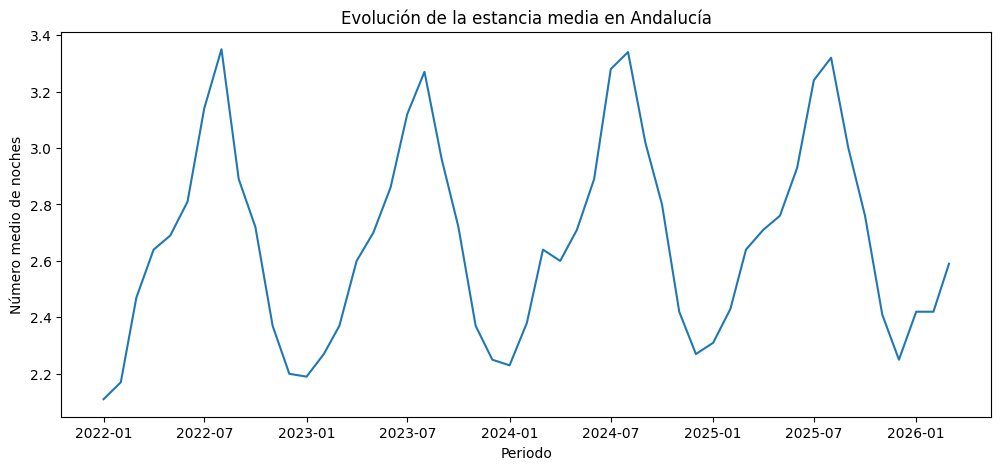

In [116]:
import matplotlib.pyplot as plt

# Filtrar agregado de Andalucía
df_grafico = df_e[
    (df_e["Comunidades y Ciudades Autónomas"] == "Andalucía") &
    (df_e["Provincia limpia"] == "Total comunidad autónoma")
]

# Crear gráfico
plt.figure(figsize=(12, 5))

plt.plot(
    df_grafico["Periodo fecha"],
    df_grafico["Estancia media"]
)

# Título y etiquetas
plt.title("Evolución de la estancia media en Andalucía")
plt.xlabel("Periodo")
plt.ylabel("Número medio de noches")

# Mostrar gráfico
plt.show()